In [1]:
"""
image processing:
    histogram esitleme: kontsrat iyileştirme
    gaussian blur: gürültü azaltma
    canny edge detection: kenar tespiti


"""

'\nimage processing:\n    histogram esitleme: kontsrat iyileştirme\n    gaussian blur: gürültü azaltma\n    canny edge detection: kenar tespiti\n\n\n'

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist #veri seti
from tensorflow.keras.models import Sequential #ann modeli
from tensorflow.keras.layers import Dense,Dropout #ann katmanları
from tensorflow.keras.optimizers import Adam #optimizasyon

In [3]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [4]:
img=X_train[4]

In [5]:
stages={"orijinal":img}

In [6]:
#histogram eşitleme
eq=cv2.equalizeHist(img)
stages['histogram esitleme']=eq

#gürültü azatlma
blur=cv2.GaussianBlur(eq,(5,5),0)
stages['blur']=blur

#canny ile kenar tespiti
edges=cv2.Canny(blur,50,150) #150 üst eşik deeğer üstü kenar olarak alını 
stages['canny']=edges        #50'nin altı alınmaz arası ise zayıf adaydır

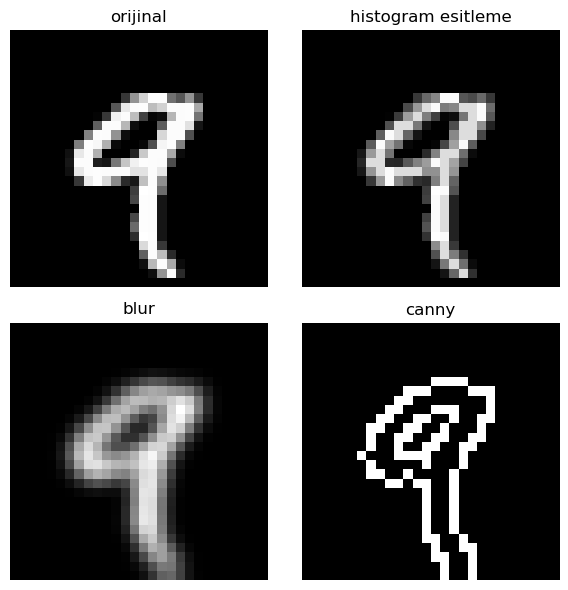

In [7]:
#görselleştirme
fig,axes=plt.subplots(2,2,figsize=(6,6))
axes=axes.flat
for ax,(title,im) in zip(axes,stages.items()):
    ax.imshow(im,cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
def preprocess_image(img):
    eq=cv2.equalizeHist(img)
    blur=cv2.GaussianBlur(eq,(5,5),0)
    edges=cv2.Canny(blur,50,150)
    features=edges.flatten()/255.0
    return features

In [9]:
num_of_train=10000
num_of_test=2000

In [10]:
X_train=np.array([preprocess_image(img) for img in X_train[:num_of_train]])

In [11]:
y_train=y_train[:num_of_train]

In [12]:
X_test=np.array([preprocess_image(img) for img in X_test[:num_of_test]])
y_test=y_test[:num_of_test]

In [13]:
#model kurulumu ANN


In [14]:
model=Sequential(
    [
    Dense(128,activation='relu',input_shape=(784,)),
    Dropout(0.3),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
    ]
)

C:\Users\Ömer faruk\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer=Adam(learning_rate=0.001),loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history=model.fit(
    X_train,y_train,
    validation_data=(X_test,y_test),
    epochs=10,
    batch_size=32,
    verbose=2
)

Epoch 1/10
313/313 - 1s - 5ms/step - accuracy: 0.6994 - loss: 0.9513 - val_accuracy: 0.8200 - val_loss: 0.5799
Epoch 2/10
313/313 - 1s - 2ms/step - accuracy: 0.8590 - loss: 0.4571 - val_accuracy: 0.8510 - val_loss: 0.4787
Epoch 3/10
313/313 - 1s - 2ms/step - accuracy: 0.8919 - loss: 0.3451 - val_accuracy: 0.8635 - val_loss: 0.4484
Epoch 4/10
313/313 - 1s - 2ms/step - accuracy: 0.9155 - loss: 0.2674 - val_accuracy: 0.8695 - val_loss: 0.4186
Epoch 5/10
313/313 - 1s - 2ms/step - accuracy: 0.9339 - loss: 0.2175 - val_accuracy: 0.8700 - val_loss: 0.4158
Epoch 6/10
313/313 - 1s - 2ms/step - accuracy: 0.9444 - loss: 0.1746 - val_accuracy: 0.8795 - val_loss: 0.4008
Epoch 7/10
313/313 - 1s - 2ms/step - accuracy: 0.9530 - loss: 0.1421 - val_accuracy: 0.8765 - val_loss: 0.4125
Epoch 8/10
313/313 - 1s - 2ms/step - accuracy: 0.9665 - loss: 0.1099 - val_accuracy: 0.8830 - val_loss: 0.4298
Epoch 9/10
313/313 - 1s - 2ms/step - accuracy: 0.9671 - loss: 0.0992 - val_accuracy: 0.8830 - val_loss: 0.4511
E

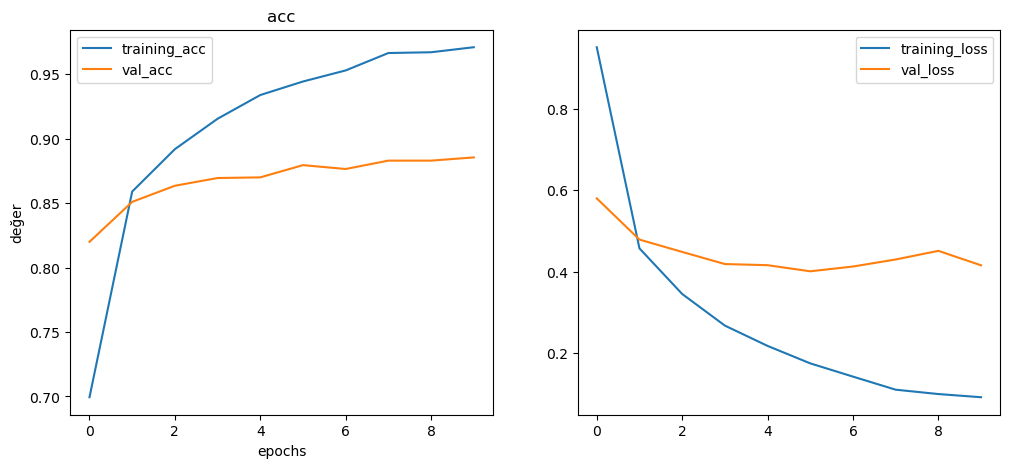

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"],label="training_acc")
plt.plot(history.history["val_accuracy"],label="val_acc")
plt.title("acc")
plt.xlabel("epochs")
plt.ylabel("değer")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"],label="training_loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend()

plt.show()